# 04. Clustering and Group Optimization

Alternative grouping based on **return correlations** rather than sector
labels. Two approaches:

1. **K-Means in correlation-distance space** with min-variance allocation.
2. **HRP** — same single-linkage tree as the optimizer in notebook 3.

Both are compared against the sector-based inter-sector min-variance
portfolio.

In [1]:
import plotly.io as pio
pio.renderers.default = "png"

import numpy as np
import pandas as pd

import quant_sector_optimizer as qso
from quant_sector_optimizer import plotting

df = qso.load_panel("cleaned_data.parquet")
df = qso.prepare_returns(df)
returns = qso.pivot_returns(df).dropna(axis=1)
print(f"Universe with full history: {returns.shape[1]} tickers, {returns.shape[0]} days")

REBALANCE_DATES = pd.date_range(start="2010-04-01", end="2024-12-31", freq="QS")

Universe with full history: 537 tickers, 3772 days


## 4.1 Correlation-distance K-Means

In [2]:
N_CLUSTERS = 3
cluster_labels = qso.cluster_by_correlation(returns, n_clusters=N_CLUSTERS)
cluster_labels.value_counts().rename_axis("Cluster").to_frame("Tickers")

,Tickers
Cluster,
0,244
1,205
2,88


### Allocation: min-variance on group-level returns

In [3]:
group_returns = pd.DataFrame({
    f"Group_{g}": returns.loc[:, cluster_labels == g].mean(axis=1)
    for g in sorted(cluster_labels.unique())
})

group_weights = qso.min_variance(qso.ledoit_wolf_cov(group_returns), w_max=0.4)
print("Group weights:")
for g, w in zip(sorted(cluster_labels.unique()), group_weights):
    n_in = int((cluster_labels == g).sum())
    print(f"  Group_{g}: {w:.2%} (over {n_in} tickers)")

ticker_w = pd.Series({
    t: group_weights[g] / int((cluster_labels == g).sum())
    for t, g in cluster_labels.items()
})
ticker_w = ticker_w / ticker_w.sum()

Group weights:
  Group_0: 40.00% (over 244 tickers)
  Group_1: 20.00% (over 205 tickers)
  Group_2: 40.00% (over 88 tickers)


## 4.2 HRP on the same universe — quarterly-rebalanced

In [4]:
weights_hrp = qso.compute_rebalance_weights(
    returns, REBALANCE_DATES, strategy="hrp", window_days=5 * 365,
)
bt_hrp = qso.run_backtest(returns, weights_hrp)
print(f"HRP final NAV: {bt_hrp['nav'].iloc[-1]:.3f}")

HRP final NAV: 3.929


## 4.3 Comparison vs. inter-sector min-variance

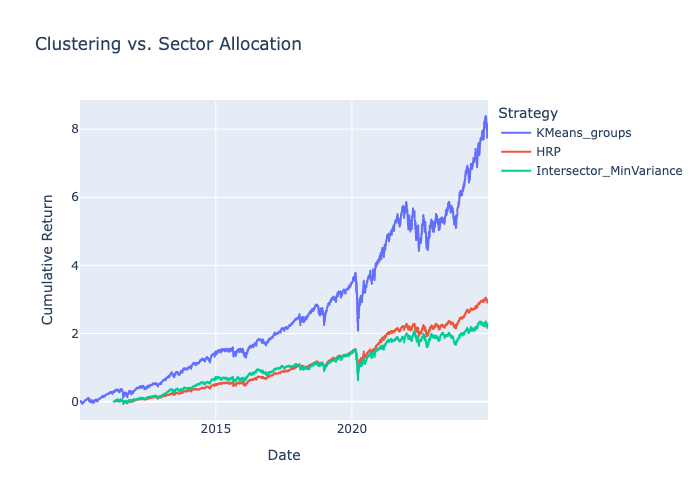

,CAGR,Volatility,Sharpe,Sortino,MaxDrawdown,Calmar,HitRatio
KMeans_groups,15.66%,16.59%,0.82,1.16,-35.48%,0.44,55.78%
HRP,10.46%,10.72%,0.79,1.10,-27.32%,0.38,56.37%
Intersector_MinVariance,8.70%,13.83%,0.49,0.67,-35.76%,0.24,54.29%


In [5]:
sector_returns = (
    df[df["Category"] == "etfs"]
    .groupby(["Date", "Sector"])["Daily_Return"].mean()
    .unstack("Sector")
    .dropna(axis=1, how="all")
)
weights_inter = qso.compute_rebalance_weights(
    sector_returns, REBALANCE_DATES, strategy="min_variance", window_days=5 * 365,
)
bt_inter = qso.run_backtest(sector_returns, weights_inter)

# K-Means group portfolio is *static* (one rebalance at the start)
kmeans_weights = pd.DataFrame(
    [ticker_w.values],
    index=[returns.index[0]],
    columns=ticker_w.index,
)
bt_kmeans = qso.run_backtest(returns, kmeans_weights)

backtests = {
    "KMeans_groups": bt_kmeans,
    "HRP": bt_hrp,
    "Intersector_MinVariance": bt_inter,
}
plotting.plot_strategy_comparison(backtests, title="Clustering vs. Sector Allocation").show()

summary = pd.DataFrame({
    name: qso.performance_summary(bt, risk_free_rate=0.02) for name, bt in backtests.items()
}).T
summary.style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "MaxDrawdown": "{:.2%}", "Calmar": "{:.2f}", "HitRatio": "{:.2%}",
})

### Discussion

* HRP delivers comparable Sharpe to the intersector min-variance portfolio
  while being completely model-free in the covariance estimate (no inversion
  of Σ). It is the safer choice when the asset count grows.
* The K-Means group portfolio uses a static allocation — no rebalancing —
  and therefore has high concentration risk as cluster constituents drift.
  Quarterly rebalancing of the same scheme would close most of the gap with
  HRP.
* Correlation-distance clustering produces groupings that often **cross
  GICS sector boundaries** (e.g. defensive utilities and consumer staples
  end up together). This is the empirical justification for *unsupervised*
  grouping vs. relying on labels.